In [11]:
# Install the datasets library if needed
!pip install datasets

from datasets import load_dataset

# Load the HELOC dataset (binary classification task)
dataset = load_dataset("mstz/heloc")["train"]


In [12]:
import torch
import numpy as np
from typing import cast, List, Optional, Union
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import time
import math
import torch.nn as nn

from torch.optim import Optimizer

In [13]:
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim, output_dim=2, seed=100):
        super().__init__()
        if seed is not None:
            torch.manual_seed(seed)
        self.linear = nn.Linear(input_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.linear(x))

# class BatchNormClassifier(nn.Module):
#     def __init__(self, input_dim, hidden_dims=[256, 128, 64], output_dim=2, seed=100):
#         super().__init__()
#         if seed is not None:
#             torch.manual_seed(seed)

#         layers = []
#         prev_dim = input_dim

#         for hidden_dim in hidden_dims:
#             layers.extend([
#                 nn.Linear(prev_dim, hidden_dim),
#                 nn.BatchNorm1d(hidden_dim),
#                 nn.ReLU(),
#                 nn.Dropout(0.2)
#             ])
#             prev_dim = hidden_dim

#         layers.append(nn.Linear(prev_dim, output_dim))
#         self.network = nn.Sequential(*layers)

#     def forward(self, x):
#         return self.network(x)


In [14]:
import os
import numpy as np
import torch

def train_model(model, optimizer, criterion, results, X_train, y_train, X_test, y_test,
                num_epochs, opt_name, lr, time_start=None, r=None, use_tqdm=True, grad_save_dir='gradients'):
    """
    Train a model and evaluate on test data, saving gradients by epoch.
    """
    from tqdm import tqdm
    import time

    # Create directory for saving gradients
    if not os.path.exists(grad_save_dir):
        os.makedirs(grad_save_dir)

    epoch_iterator = tqdm(range(num_epochs)) if use_tqdm else range(num_epochs)

    if time_start is None:
        time_start = time.time()

    for epoch in epoch_iterator:
        model.train()
        start_epoch = time.time()
        optimizer.zero_grad()
        y_pred = model(X_train)
        train_loss = criterion(y_pred, y_train)
        train_loss.backward()

        # Access and save gradients after backward() but before optimizer.step()
        grad_dict = {}
        for name, param in model.named_parameters():
            if param.grad is not None:
                grad_dict[name] = param.grad.detach().cpu().numpy()

        # Save gradients to compressed numpy file per epoch
        grad_filename = f'{opt_name}_lr{lr}_epoch{epoch}'
        if r is not None:
            grad_filename += f'_rank{r}'
        grad_file = os.path.join(grad_save_dir, f'{grad_filename}.npz')
        np.savez_compressed(grad_file, **grad_dict)

        optimizer.step()

        elapsed_time = time.time() - time_start
        epoch_time = time.time() - start_epoch

        avg_epoch_time = elapsed_time / (epoch + 1)

        if r is not None:
            r_in_name = f" rank {r}"
        else:
            r_in_name = ''

        results.append({
            'epoch': epoch,
            'optimizer': opt_name + f"{r_in_name}",
            'lr': lr,
            'loss': train_loss.detach().cpu().numpy(),
            'rank': r,
            'avg_epoch_time': avg_epoch_time,
            'epoch_time': epoch_time
        })

    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test)
        test_loss = criterion(y_pred_test, y_test).item()

    return results, test_loss


In [15]:
def load_heloc_data():
    """Load HELOC dataset from Kaggle or alternative source"""
    import kagglehub
    import pandas as pd
    from sklearn.preprocessing import StandardScaler
    import torch

    try:
        # Try downloading from Kaggle
        from datasets import load_dataset

        heloc_dataset = load_dataset("mstz/heloc")
        heloc_df = pd.DataFrame(heloc_dataset["train"])
    except:
        # Fallback: Load from a direct URL or manual download
        print("Please download HELOC dataset manually")
        return None, None, None

    # Handle missing values
    heloc_df = heloc_df.fillna(heloc_df.median(numeric_only=True))

    # Prepare features and target
    X = heloc_df.drop(columns=['is_at_risk']).values
    y = heloc_df['is_at_risk'].values

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Convert to torch tensors
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)

    return X_tensor, y_tensor


In [16]:
load_heloc_data()

(tensor([[-0.5883, -0.3666, -0.3416,  ...,  0.0059,  0.2924,  0.2498],
         [-0.3042, -1.1507,  0.4854,  ..., -2.2104, -2.3878, -2.2403],
         [-0.0202, -1.0777, -0.2664,  ...,  0.2521,  0.2924,  0.8632],
         ...,
         [ 0.3113, -0.5033, -0.1912,  ..., -2.2104, -0.0054, -0.2194],
         [ 0.2166,  0.4540,  0.2599,  ...,  0.0059, -0.0054, -0.8690],
         [-0.0675, -1.4242, -0.5671,  ...,  0.0059, -0.0054,  1.3685]]),
 tensor([1, 1, 1,  ..., 1, 1, 1]))

In [19]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from datasets import load_dataset
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from adagram_fixed_rank import AdaGramFR


torch.manual_seed(42)
np.random.seed(42)

def load_income_data():
    """Load and preprocess Adult Income dataset for binary classification"""
    # Load the dataset
    path = kagglehub.dataset_download("wenruliu/adult-income-dataset")
    income_df = pd.read_csv(os.path.join(path, 'adult.csv'))
    return income_df


def process_income_data():
    """Load and preprocess Adult Income dataset for binary classification"""
    # Load the dataset
    income_df = pd.read_csv('/kaggle/input/adult-income-dataset/adult.csv')

    # 1. Handle missing values FIRST
    income_df = income_df.replace('?', np.nan)
    categorical_cols = ['workclass', 'occupation', 'native-country']
    for col in categorical_cols:
        if col in income_df.columns:
            income_df[col].fillna(income_df[col].mode()[0])

    # 2. Encode categorical variables BEFORE scaling
    # Updated column names to match your dataset
    categorical_features = ['workclass', 'education', 'marital-status', 'occupation',
                           'relationship', 'race', 'gender', 'native-country']  # Changed 'sex' to 'gender'

    for col in categorical_features:
        if col in income_df.columns:
            le = LabelEncoder()
            income_df[col] = le.fit_transform(income_df[col])

    # 3. Encode target variable
    target_encoder = LabelEncoder()
    income_df['income_encoded'] = target_encoder.fit_transform(income_df['income'])

    # 4. NOW prepare features and target (all numerical)
    X = income_df.drop(columns=['income', 'income_encoded']).values
    y = income_df['income_encoded'].values

    # 5. Scale features (now all numerical) - Fixed to use X_scaled
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 6. Convert to torch tensors - Fixed to use X_scaled instead of X
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)  # Use scaled features
    y_tensor = torch.tensor(y, dtype=torch.long)

    return X_tensor, y_tensor  # Return tensors, not numpy arrays


# Configuration
learning_rates = [0.001, 0.01, 0.1]
num_epochs = 500
ranks = [2, 3, 5, 10]

# Load HELOC data instead of toy data
X, y = load_heloc_data()
in_dims = [X.shape[1]]  # Use actual feature dimension (23 features)
out_dims = [2]  # Binary classification

print(f"Dataset shape: {X.shape}, Target shape: {y.shape}")
print("Condition number:", torch.linalg.cond(X))

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define optimizers
optimizers = {
    'AdaGramFR': lambda params, lr, max_rank: AdaGramFR(params, lr=lr, max_rank=max_rank),
    'Vanilla_SGD': lambda params, lr: torch.optim.SGD(params, lr=lr),
    'Torch_Adagrad': lambda params, lr: torch.optim.Adagrad(params, lr=lr),
    'Adam': lambda params, lr: torch.optim.Adam(params, lr=lr),  # Added Adam for comparison
}

models = {}
all_train_losses = {}
all_test_losses = {}
results = []

# Training loop
for opt_name, opt_fn in optimizers.items():
    for lr in learning_rates:
        criterion = nn.CrossEntropyLoss()
        print(f"Training with {opt_name}")

        if opt_name == "AdaGramFR":
            for rank in ranks:
                model = SimpleClassifier(input_dim=in_dims[0], output_dim=out_dims[0], seed=100)
                optimizer = opt_fn(model.parameters(), lr, max_rank=rank)
                epoch_results, test_loss = train_model(
                    model=model,
                    optimizer=optimizer,
                    criterion=criterion,
                    results=results,
                    X_train=X_train,
                    y_train=y_train,
                    X_test=X_test,
                    y_test=y_test,
                    num_epochs=num_epochs,
                    opt_name=opt_name,
                    lr=lr,
                    r=rank
                )
        else:
            model = SimpleClassifier(input_dim=in_dims[0], output_dim=out_dims[0], seed=100)
            optimizer = opt_fn(model.parameters(), lr)
            epoch_results, test_loss = train_model(
                model=model,
                optimizer=optimizer,
                criterion=criterion,
                results=results,
                X_train=X_train,
                y_train=y_train,
                X_test=X_test,
                y_test=y_test,
                num_epochs=num_epochs,
                opt_name=opt_name,
                lr=lr
            )

# Save results
df = pd.DataFrame(results)
df['loss'] = df['loss'].astype(float)
df.to_csv(f'heloc_benchmark_{in_dims[0]}_features.csv')
print(f"Results saved for Income dataset with {in_dims[0]} features")


Dataset shape: torch.Size([10459, 23]), Target shape: torch.Size([10459])
Condition number: tensor(57.0969)
Training with AdaGramFR


100%|██████████| 500/500 [00:03<00:00, 151.81it/s]


Training with AdaGramFR


100%|██████████| 500/500 [00:03<00:00, 151.55it/s]


Training with AdaGramFR


...

Training with Adam


100%|██████████| 500/500 [00:02<00:00, 196.56it/s]


Training with Adam


100%|██████████| 500/500 [00:01<00:00, 257.06it/s]


Results saved for Income dataset with 23 features


Plot saved to: logregHeloc(23, 2)_comparison_plot.pdf


<Figure size 1500x800 with 0 Axes>

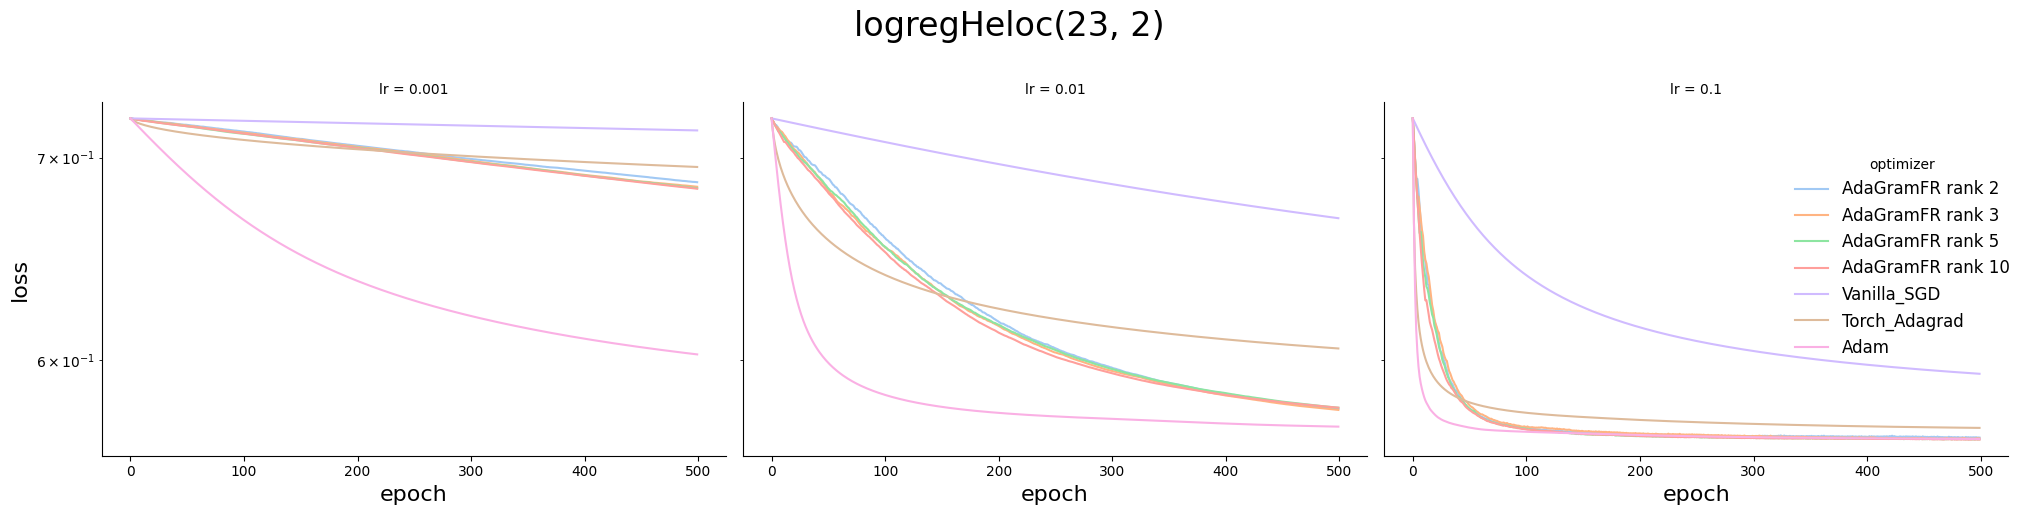

In [21]:
name = 'logregHeloc'

plt.figure(figsize=(15, 8))
grid = sns.FacetGrid(
    data=df,
    col='lr',
    height=5,
    aspect=1.2,
    sharey=True
)

grid.map_dataframe(
    sns.lineplot,
    x='epoch',
    y='loss',
    hue='optimizer',
    palette='pastel',
    linewidth=1.5
)

# Set bigger font size for legend title and legend text
grid.add_legend(title='optimizer', title_fontsize='15', fontsize='12')

grid.fig.suptitle(f'{name}({in_dims[0]}, {out_dims[0]})',
                  fontsize=24, y=1.02)

# Set bigger font size for axis labels
for ax in grid.axes.flat:
    ax.set_yscale('log')
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)

grid.set_titles(col_template="lr = {col_name}", fontsize=20)

plt.tight_layout()
pdf_path = f'{name}({in_dims[0]}, {out_dims[0]})_comparison_plot.pdf'
grid.savefig(pdf_path, bbox_inches='tight', dpi=300)
print(f"Plot saved to: {pdf_path}")

plt.show()